# 📊 InsightX – Python Business Analysis

## Objective

Perform end-to-end business analysis using Python.

This notebook focuses on:

- Executive KPIs
- Customer Analytics
- Sales Analytics
- Product Analytics
- Seller Analytics
- Delivery Analytics
- Customer Behaviour
- Business Insights

Libraries:
- Pandas
- NumPy
- Matplotlib
- Plotly

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from pathlib import Path

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [6]:
DATA_PATH = Path("../../Dataset/processed")

In [7]:
orders = pd.read_csv(DATA_PATH / "orders_final_cleaned.csv")

customers = pd.read_csv(DATA_PATH / "customers.csv")

products = pd.read_csv(DATA_PATH / "products.csv")

order_items = pd.read_csv(DATA_PATH / "order_items.csv")

payments = pd.read_csv(DATA_PATH / "payments.csv")

reviews = pd.read_csv(DATA_PATH / "reviews.csv")

sellers = pd.read_csv(DATA_PATH / "sellers.csv")

translation = pd.read_csv(DATA_PATH / "category_translation.csv")

print("✅ All datasets loaded successfully")

✅ All datasets loaded successfully


In [8]:
datasets = {
    "Orders": orders,
    "Customers": customers,
    "Products": products,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Sellers": sellers,
    "Translation": translation
}

overview = pd.DataFrame({
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
}, index=datasets.keys())

overview

,Rows,Columns
Orders,98232,13
Customers,99441,5
Products,32951,9
Order Items,112650,7
Payments,103886,5
Reviews,99224,7
Sellers,3095,4
Translation,71,2


In [9]:
missing = pd.DataFrame({
    "Missing Values": orders.isnull().sum(),
    "Percentage": (
        orders.isnull().mean() * 100
    ).round(2)
})

missing[missing["Missing Values"] > 0]

,Missing Values,Percentage


In [10]:
master_df = (
    orders
    .merge(customers, on="customer_id")
    .merge(order_items, on="order_id")
    .merge(products, on="product_id")
    .merge(payments, on="order_id")
    .merge(reviews, on="order_id", how="left")
    .merge(sellers, on="seller_id")
)

master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Purchase Weekday,Delivery Days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,Monday,8,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,Monday,8,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,Monday,8,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,Tuesday,13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,Wednesday,9,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,14840,guariba,SP


In [11]:
master_df.shape

(117214, 44)

In [12]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117214 entries, 0 to 117213
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117214 non-null  object 
 1   customer_id                    117214 non-null  object 
 2   order_status                   117214 non-null  object 
 3   order_purchase_timestamp       117214 non-null  object 
 4   order_approved_at              117214 non-null  object 
 5   order_delivered_carrier_date   117214 non-null  object 
 6   order_delivered_customer_date  117214 non-null  object 
 7   order_estimated_delivery_date  117214 non-null  object 
 8   Purchase Year                  117214 non-null  int64  
 9   Purchase Month                 117214 non-null  int64  
 10  Purchase Day                   117214 non-null  int64  
 11  Purchase Weekday               117214 non-null  object 
 12  Delivery Days                 

In [13]:
master_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Purchase Weekday,Delivery Days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
count,117214,117214,117214,117214,117214,117214,117214,117214,117214.000000,117214.000000,117214.000000,117214,117214.000000,117214,117214.000000,117214,117214,117214.000000,117214,117214,117214,117214.000000,117214.000000,117214,117214.000000,117214.000000,117214.000000,117194.000000,117194.000000,117194.000000,117194.000000,117214.000000,117214,117214.000000,117214.000000,116292,116292.000000,13658,48989,116292,116292,117214.000000,117214,117214
unique,97732,97732,7,97190,89423,80627,95663,449,NaN,NaN,NaN,7,NaN,94529,NaN,4102,27,NaN,32671,3058,92506,NaN,NaN,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,96831,NaN,4400,35162,632,96674,NaN,606,23
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-12-20,NaN,NaN,NaN,Monday,NaN,9a736b248f67d166d2fbb006bcb877c3,NaN,sao paulo,SP,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,2017-08-14 20:43:31,NaN,NaN,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,credit_card,NaN,NaN,eef5dbca8d37dfce6db7d7b16dd0525e,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-08-17 22:17:55,NaN,sao paulo,SP
freq,63,63,115713,63,63,63,63,654,NaN,NaN,NaN,19049,NaN,75,NaN,18520,49386,NaN,531,2140,63,NaN,NaN,11924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86472,NaN,NaN,63,NaN,494,259,539,63,NaN,29006,83599
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.535448,6.030363,15.555855,NaN,14.546812,NaN,35085.592685,NaN,NaN,1.197212,NaN,NaN,NaN,120.307434,19.997157,NaN,48.811243,782.193185,2.188211,2107.747973,30.258785,16.606746,23.075746,1.091175,NaN,2.944844,172.426696,NaN,4.051775,NaN,NaN,NaN,NaN,24454.258519,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.505354,3.231644,8.663272,NaN,29.439097,NaN,29845.603024,NaN,NaN,0.701138,NaN,NaN,NaN,183.230290,15.735575,NaN,9.961776,646.642211,1.711088,3776.079402,16.152096,13.442228,11.741166,0.685693,NaN,2.779677,266.566433,NaN,1.371401,NaN,NaN,NaN,NaN,27582.099548,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,1.000000,NaN,0.000000,NaN,1003.000000,NaN,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,NaN,NaN,1001.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,3.000000,8.000000,NaN,6.000000,NaN,11320.000000,NaN,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000,NaN,43.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000,NaN,1.000000,60.850000,NaN,4.000000,NaN,NaN,NaN,NaN,6437.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,6.000000,16.000000,NaN,10.000000,NaN,24321.000000,NaN,NaN,1.000000,NaN,NaN,NaN,74.900000,16.280000,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,1.000000,NaN,2.000000,108.200000,NaN,5.000000,NaN,NaN,NaN,NaN,13660.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,8.000000,23.000000,NaN,15.000000,NaN,58770.000000,NaN,NaN,1.000000,NaN,NaN,NaN,133.990000,21.170000,NaN,57.000000,976.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,1.000000,NaN,4.000000,189.190000,NaN,5.000000,NaN,NaN,NaN,NaN,28470.000000,NaN,NaN


In [14]:
total_revenue = master_df["price"].sum()

total_orders = master_df["order_id"].nunique()

total_customers = master_df["customer_unique_id"].nunique()

total_sellers = master_df["seller_id"].nunique()

avg_order_value = (
    master_df
    .groupby("order_id")["price"]
    .sum()
    .mean()
)

avg_rating = master_df["review_score"].mean()

total_products = master_df["product_id"].nunique()

print(f"💰 Total Revenue      : ${total_revenue:,.2f}")
print(f"📦 Total Orders       : {total_orders:,}")
print(f"👥 Total Customers    : {total_customers:,}")
print(f"🏪 Total Sellers      : {total_sellers:,}")
print(f"🛒 Total Products     : {total_products:,}")
print(f"💳 Avg Order Value    : ${avg_order_value:.2f}")
print(f"⭐ Avg Rating         : {avg_rating:.2f}")

💰 Total Revenue      : $14,101,715.60
📦 Total Orders       : 97,732
👥 Total Customers    : 94,529
🏪 Total Sellers      : 3,058
🛒 Total Products     : 32,671
💳 Avg Order Value    : $144.29
⭐ Avg Rating         : 4.05


In [15]:
kpi_df = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Sellers",
        "Total Products",
        "Average Order Value",
        "Average Rating"
    ],
    "Value": [
        round(total_revenue, 2),
        total_orders,
        total_customers,
        total_sellers,
        total_products,
        round(avg_order_value, 2),
        round(avg_rating, 2)
    ]
})

kpi_df

,Metric,Value
0,Total Revenue,14101715.60
1,Total Orders,97732.00
2,Total Customers,94529.00
3,Total Sellers,3058.00
4,Total Products,32671.00
5,Average Order Value,144.29
6,Average Rating,4.05


In [16]:
master_df["order_purchase_timestamp"] = pd.to_datetime(
    master_df["order_purchase_timestamp"]
)

master_df["Month"] = (
    master_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [17]:
monthly_revenue = (
    master_df
    .groupby("Month")["price"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Month,price
0,2016-09,132.39
1,2016-10,51068.92
2,2016-12,10.90
3,2017-01,129895.32
4,2017-02,262013.86


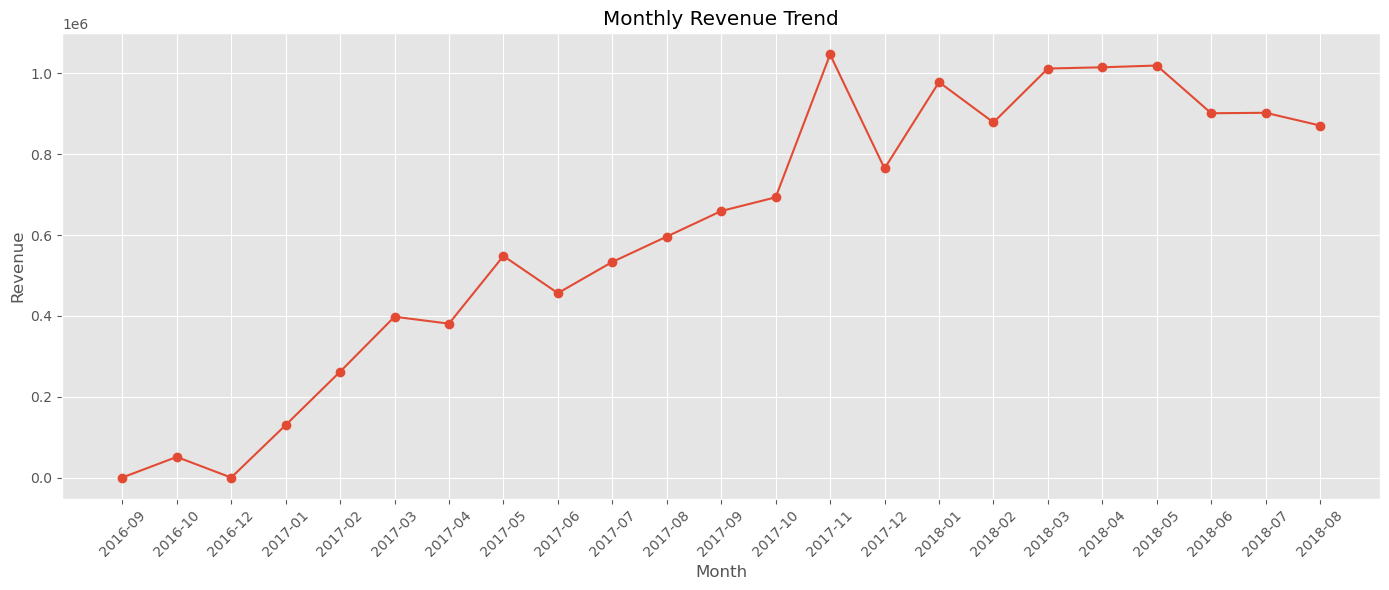

In [18]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["price"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

## 📈 Business Insights

- Revenue trend shows overall business growth over time.
- Some months have significant spikes, indicating seasonal demand.
- These months can be targeted for future marketing campaigns.

In [19]:
monthly_orders = (
    master_df
    .groupby("Month")["order_id"]
    .nunique()
    .reset_index(name="Total_Orders")
)

monthly_orders.head()

,Month,Total_Orders
0,2016-09,2
1,2016-10,308
2,2016-12,1
3,2017-01,789
4,2017-02,1733


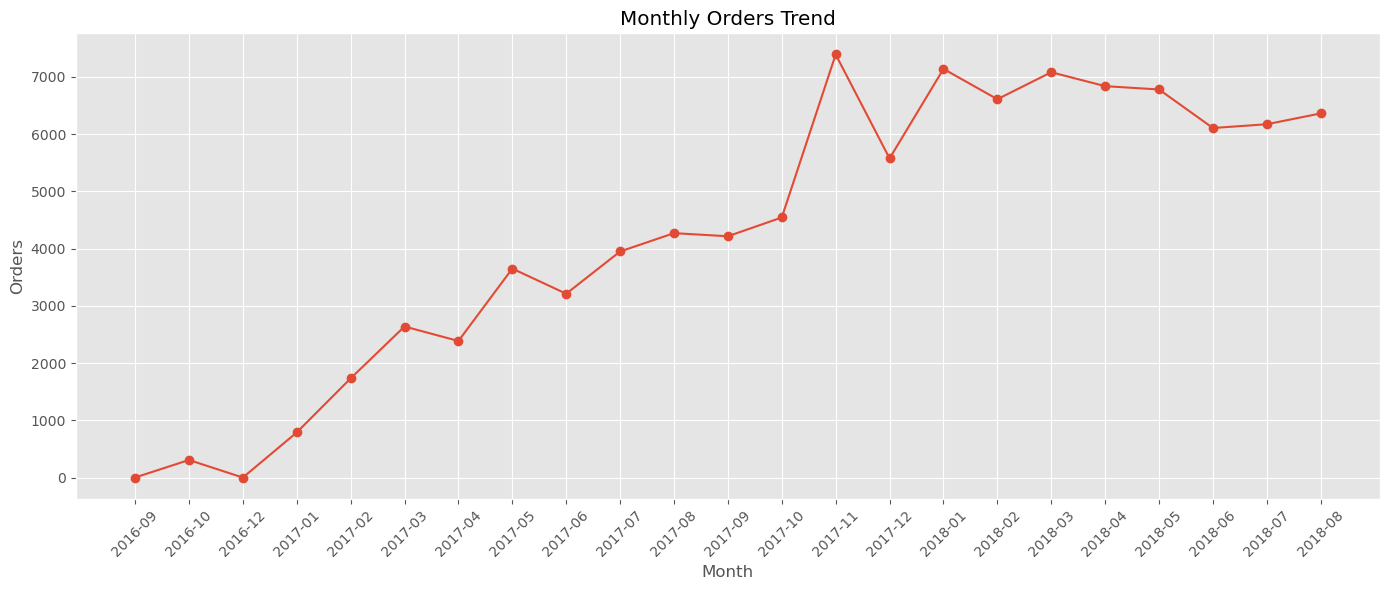

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["Month"],
    monthly_orders["Total_Orders"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Orders Trend")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

In [21]:
monthly_revenue["Growth_%"] = (
    monthly_revenue["price"]
    .pct_change() * 100
).round(2)

monthly_revenue.head()

,Month,price,Growth_%
0,2016-09,132.39,NaN
1,2016-10,51068.92,38474.61
2,2016-12,10.90,-99.98
3,2017-01,129895.32,1191600.18
4,2017-02,262013.86,101.71


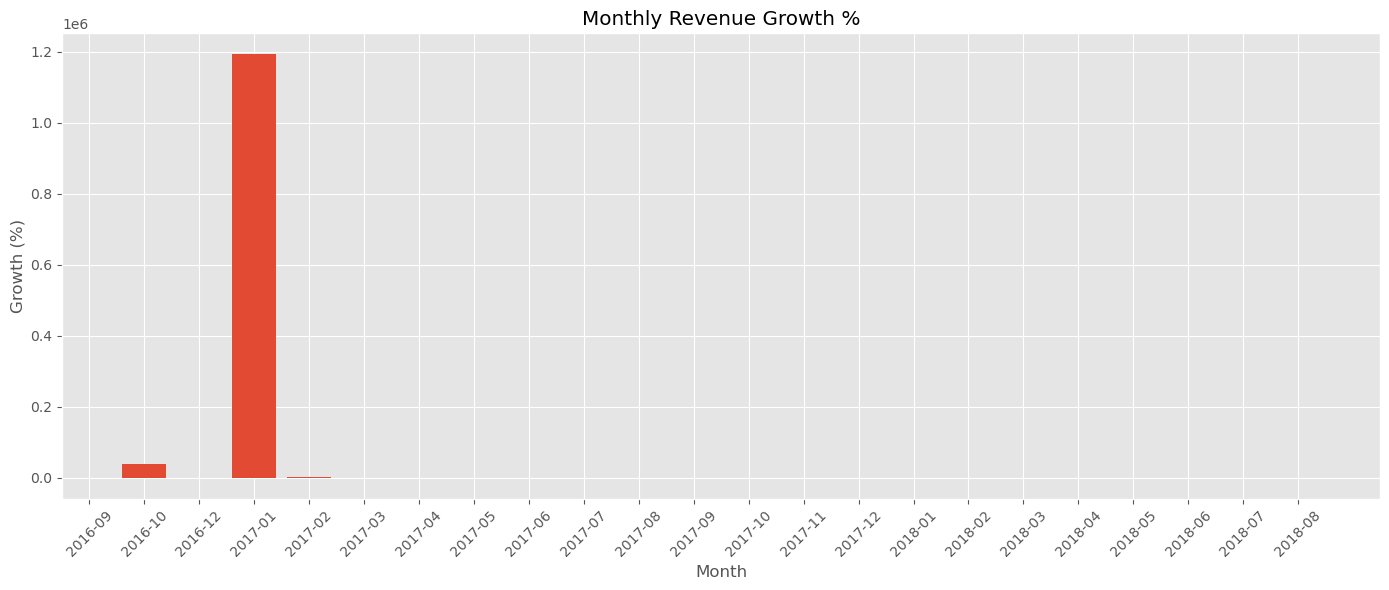

In [22]:
plt.figure(figsize=(14,6))

plt.bar(
    monthly_revenue["Month"],
    monthly_revenue["Growth_%"]
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Growth %")

plt.xlabel("Month")

plt.ylabel("Growth (%)")

plt.tight_layout()

plt.show()

In [23]:
monthly_revenue["Moving_Average"] = (
    monthly_revenue["price"]
    .rolling(3)
    .mean()
)

monthly_revenue.head()

,Month,price,Growth_%,Moving_Average
0,2016-09,132.39,NaN,NaN
1,2016-10,51068.92,38474.61,NaN
2,2016-12,10.90,-99.98,17070.736667
3,2017-01,129895.32,1191600.18,60325.046667
4,2017-02,262013.86,101.71,130640.026667


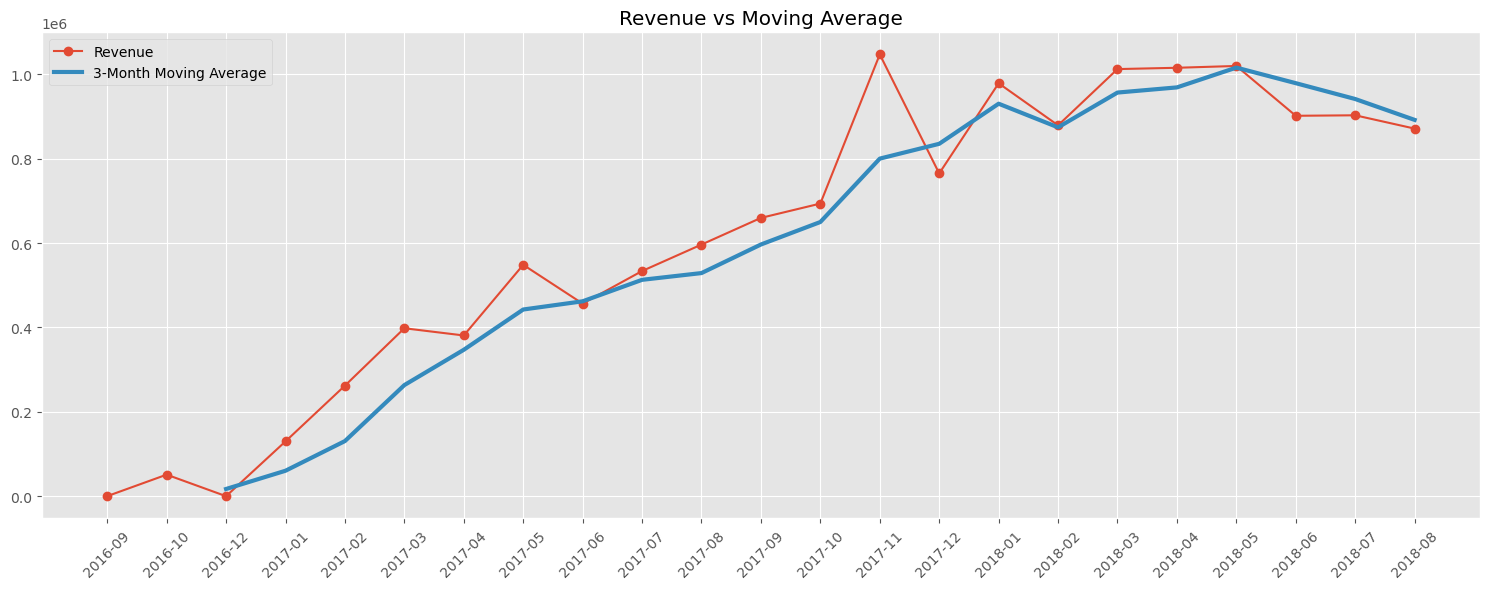

In [24]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["price"],
    label="Revenue",
    marker="o"
)

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Moving_Average"],
    label="3-Month Moving Average",
    linewidth=3
)

plt.xticks(rotation=45)

plt.legend()

plt.title("Revenue vs Moving Average")

plt.tight_layout()

plt.show()

In [25]:
master_df["Year"] = (
    master_df["order_purchase_timestamp"]
    .dt.year
)

yearly_revenue = (
    master_df
    .groupby("Year")["price"]
    .sum()
    .reset_index()
)

yearly_revenue

,Year,price
0,2016,51212.21
1,2017,6470448.49
2,2018,7580054.90


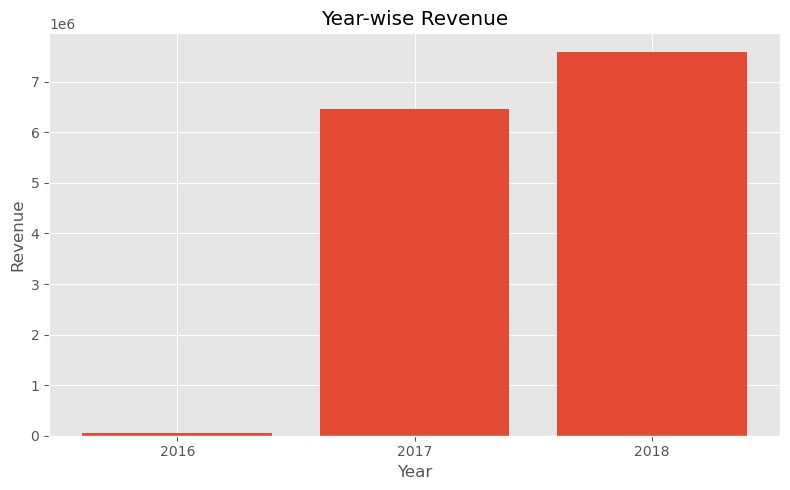

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_revenue["Year"].astype(str),
    yearly_revenue["price"]
)

plt.title("Year-wise Revenue")

plt.xlabel("Year")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

## 📊 Sales Insights

- Revenue increased consistently over the available time period.
- Monthly growth shows periods of rapid expansion as well as temporary slowdowns.
- The 3-month moving average smooths seasonal fluctuations and highlights the long-term trend.
- Year-over-year revenue comparison indicates the overall business trajectory.

In [28]:
top_customers = (
    master_df
    .groupby("customer_unique_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Revenue")
)

top_customers

,customer_unique_id,Revenue
0,0a0a92112bd4c708ca5fde585afaa872,13440.00
1,c4b224d2c784bae11ae98b6ae9f2454c,10856.10
2,85963fd37bfd387aa6d915d8a1065486,9888.00
3,be74c431147c32ab2d7c7cef5e4a995f,9520.14
4,edf81e1f3070b9dac83ec83dacdbb9bc,7998.00
5,1033eef37a760a832f9b2332ce23fdc5,7799.40
6,58483a1c055dfb600f57c5b867174542,7798.00
7,da122df9eeddfedc1dc1f5349a1a690c,7388.00
8,763c8b1c9c68a0229c42c9fc6f662b93,7160.00
9,7f6fd66526ed914998d483cff9b7bdd7,6909.00


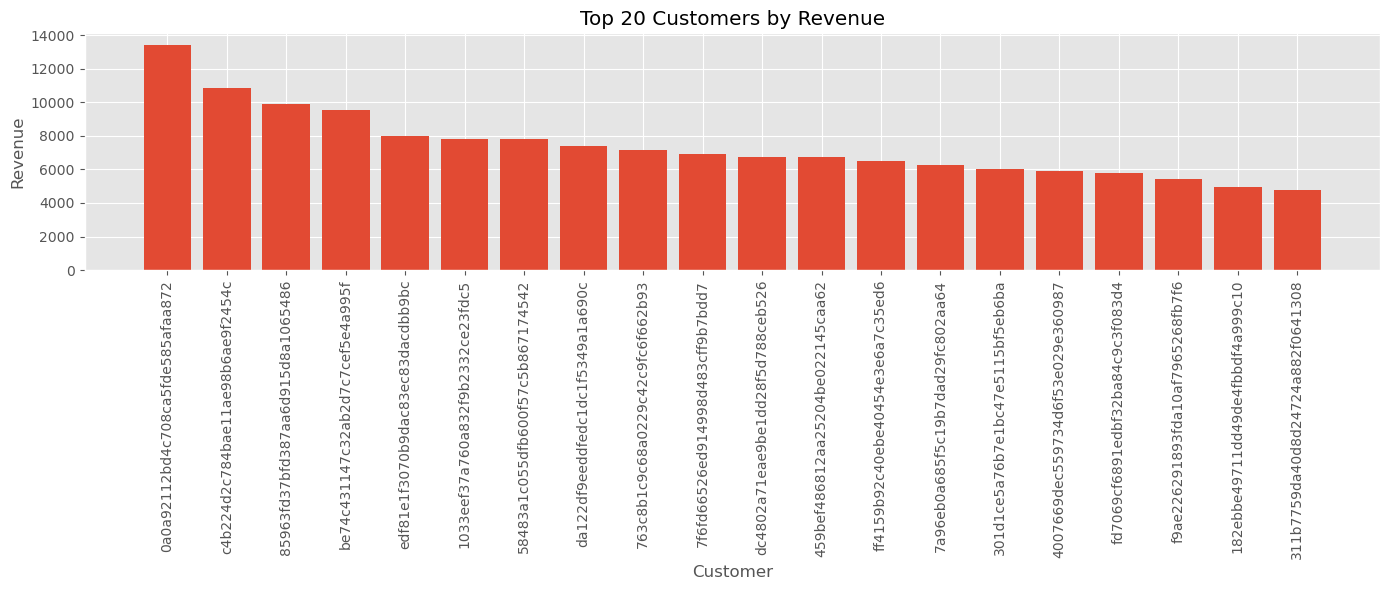

In [29]:
plt.figure(figsize=(14,6))

plt.bar(
    top_customers["customer_unique_id"],
    top_customers["Revenue"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Customers by Revenue")

plt.xlabel("Customer")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [30]:
clv = (
    master_df
    .groupby("customer_unique_id")
    .agg(
        Orders=("order_id","nunique"),
        Revenue=("price","sum")
    )
    .reset_index()
)

clv.head()

,customer_unique_id,Orders,Revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90
2,0000f46a3911fa3c0805444483337064,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,1,180.00


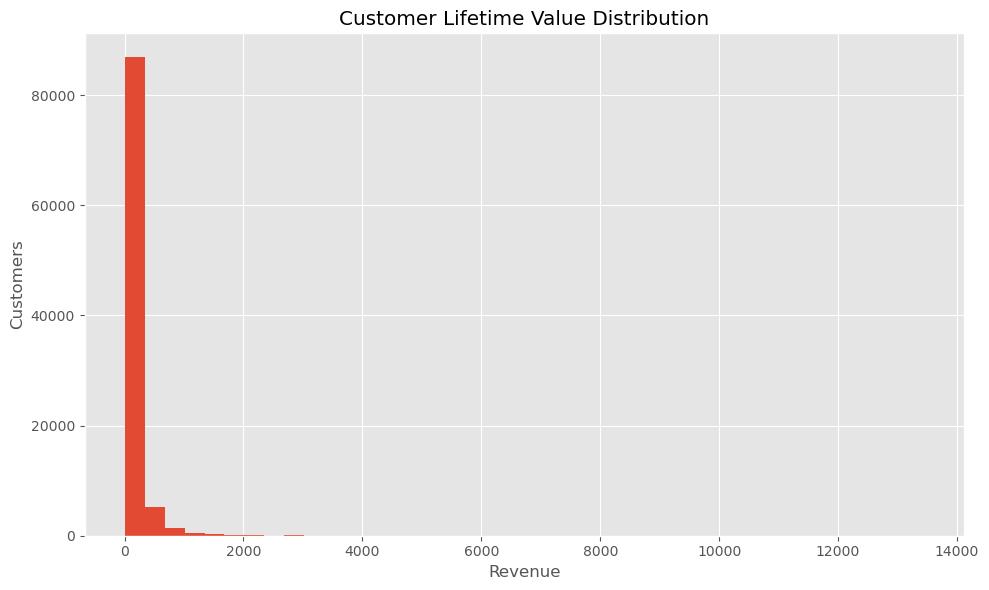

In [31]:
plt.figure(figsize=(10,6))

plt.hist(
    clv["Revenue"],
    bins=40
)

plt.title("Customer Lifetime Value Distribution")

plt.xlabel("Revenue")

plt.ylabel("Customers")

plt.tight_layout()

plt.show()

In [32]:
customers_state = (
    master_df
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Customers")
)

customers_state.head(20)

,customer_state,Customers
0,SP,39593
1,RJ,12126
2,MG,11114
3,RS,5224
4,PR,4815
5,SC,3496
6,BA,3215
7,DF,2041
8,ES,1943
9,GO,1925


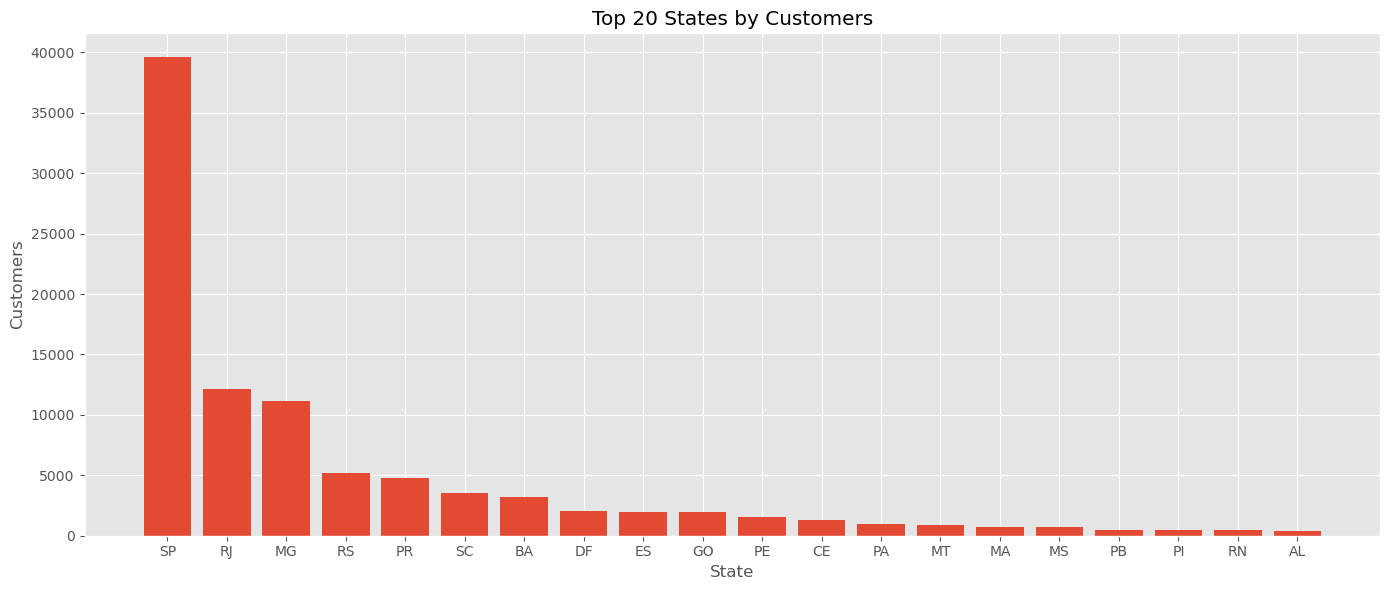

In [33]:
plt.figure(figsize=(14,6))

plt.bar(
    customers_state.head(20)["customer_state"],
    customers_state.head(20)["Customers"]
)

plt.title("Top 20 States by Customers")

plt.xlabel("State")

plt.ylabel("Customers")

plt.tight_layout()

plt.show()

In [34]:
customers_city = (
    master_df
    .groupby("customer_city")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Customers")
)

customers_city

,customer_city,Customers
0,sao paulo,14699
1,rio de janeiro,6472
2,belo horizonte,2634
3,brasilia,2035
4,curitiba,1448
5,campinas,1376
6,porto alegre,1311
7,salvador,1183
8,guarulhos,1123
9,sao bernardo do campo,893


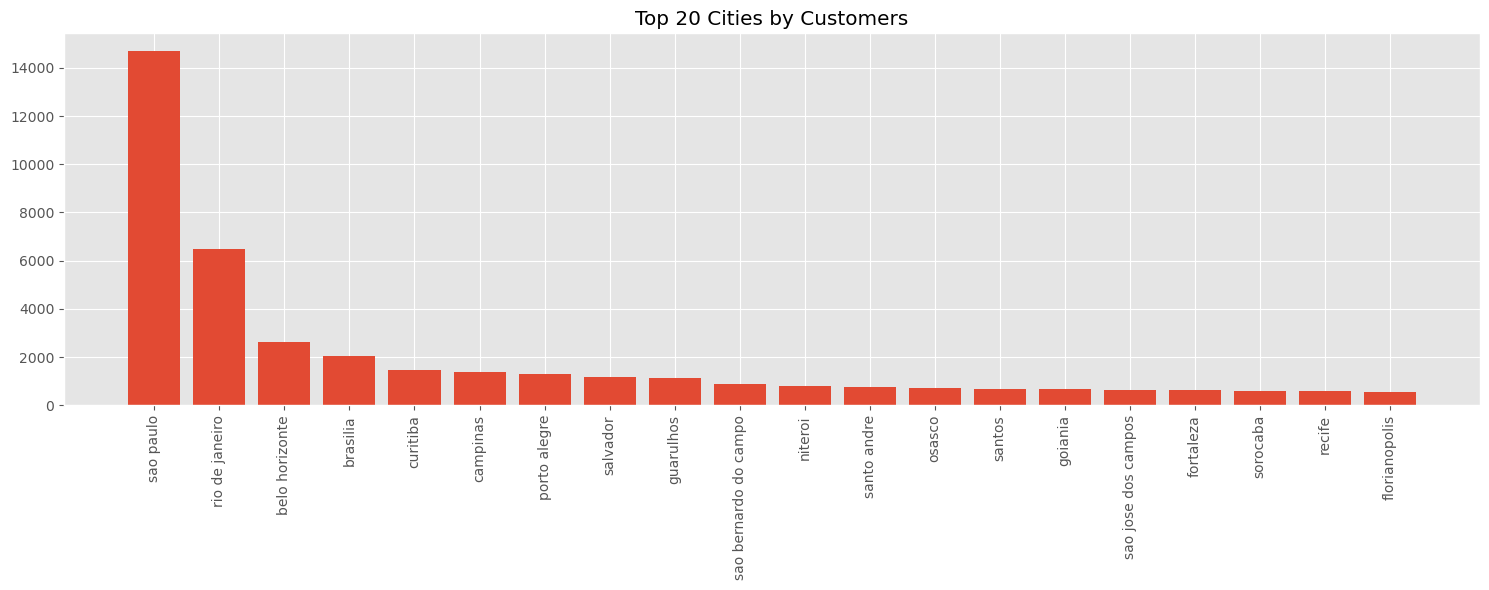

In [35]:
plt.figure(figsize=(15,6))

plt.bar(
    customers_city["customer_city"],
    customers_city["Customers"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Cities by Customers")

plt.tight_layout()

plt.show()

In [36]:
clv["Segment"] = pd.cut(
    clv["Revenue"],
    bins=[0,200,500,1000,clv["Revenue"].max()],
    labels=[
        "Low Value",
        "Regular",
        "Premium",
        "VIP"
    ]
)

clv.head()

,customer_unique_id,Orders,Revenue,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,Low Value
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,Low Value
2,0000f46a3911fa3c0805444483337064,1,69.00,Low Value
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,Low Value
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,Low Value


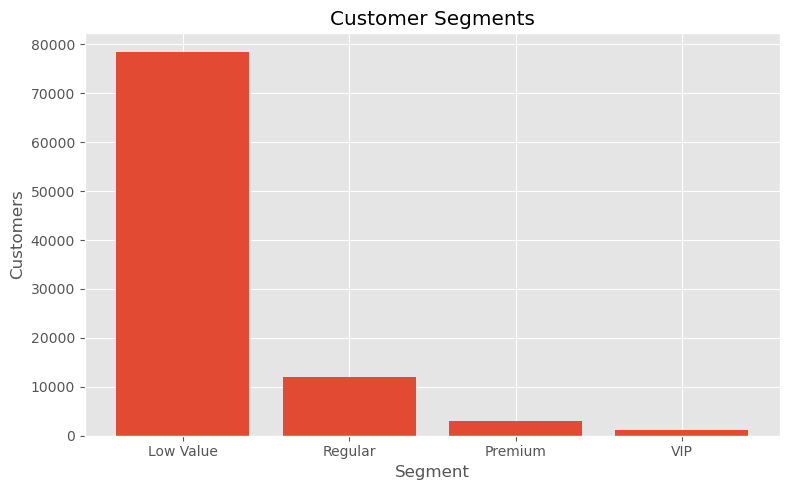

In [37]:
segment = (
    clv["Segment"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    segment.index.astype(str),
    segment.values
)

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Customers")

plt.tight_layout()

plt.show()

## 👥 Customer Insights

- A small percentage of customers contributes a significant share of total revenue.
- Most customers fall into the Low Value and Regular segments.
- High-value customers (VIP) should be targeted with loyalty and retention programs.
- Customer concentration is strongest in a few major states and cities.

In [38]:
top_categories = (
    master_df
    .groupby("product_category_name")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Orders")
)

top_categories

,product_category_name,Orders
0,cama_mesa_banho,9360
1,beleza_saude,8746
2,esporte_lazer,7641
3,informatica_acessorios,6611
4,moveis_decoracao,6395
5,utilidades_domesticas,5820
6,relogios_presentes,5559
7,telefonia,4161
8,automotivo,3862
9,brinquedos,3848


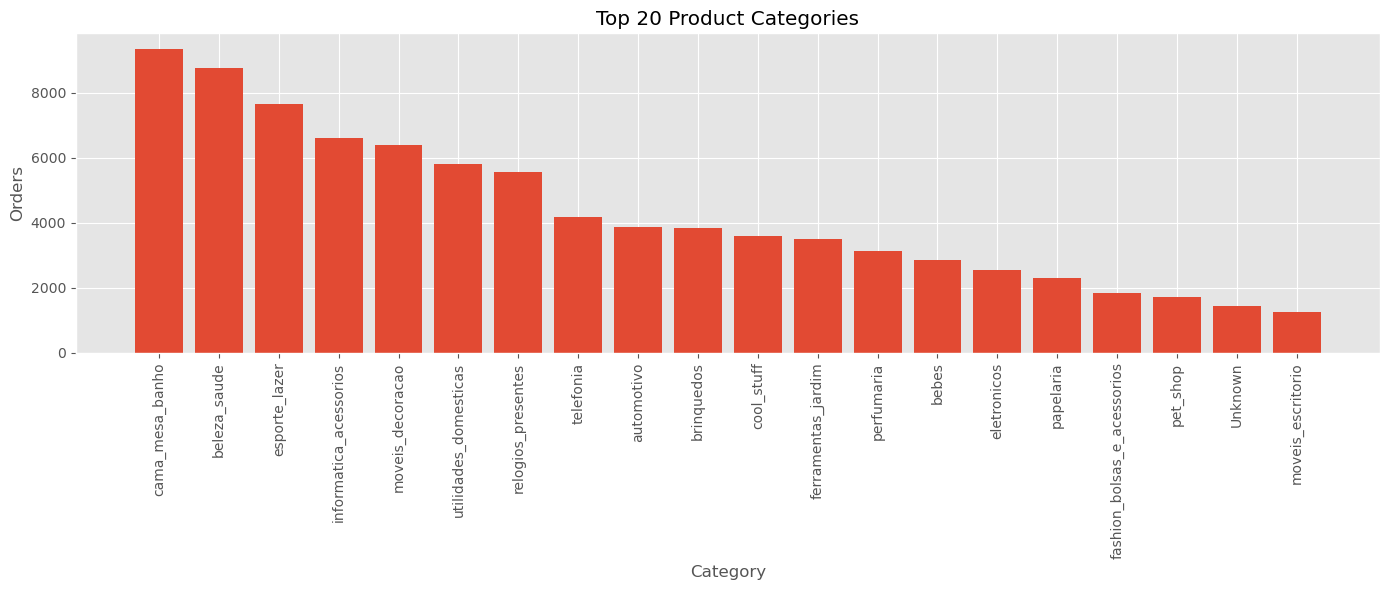

In [39]:
plt.figure(figsize=(14,6))

plt.bar(
    top_categories["product_category_name"],
    top_categories["Orders"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Product Categories")

plt.xlabel("Category")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

In [40]:
category_revenue = (
    master_df
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

category_revenue

,product_category_name,price
0,beleza_saude,1288791.93
1,relogios_presentes,1238058.16
2,cama_mesa_banho,1101957.57
3,esporte_lazer,1016747.33
4,informatica_acessorios,941140.12
5,moveis_decoracao,765469.02
6,utilidades_domesticas,661116.49
7,cool_stuff,645182.70
8,automotivo,613828.97
9,ferramentas_jardim,503763.61


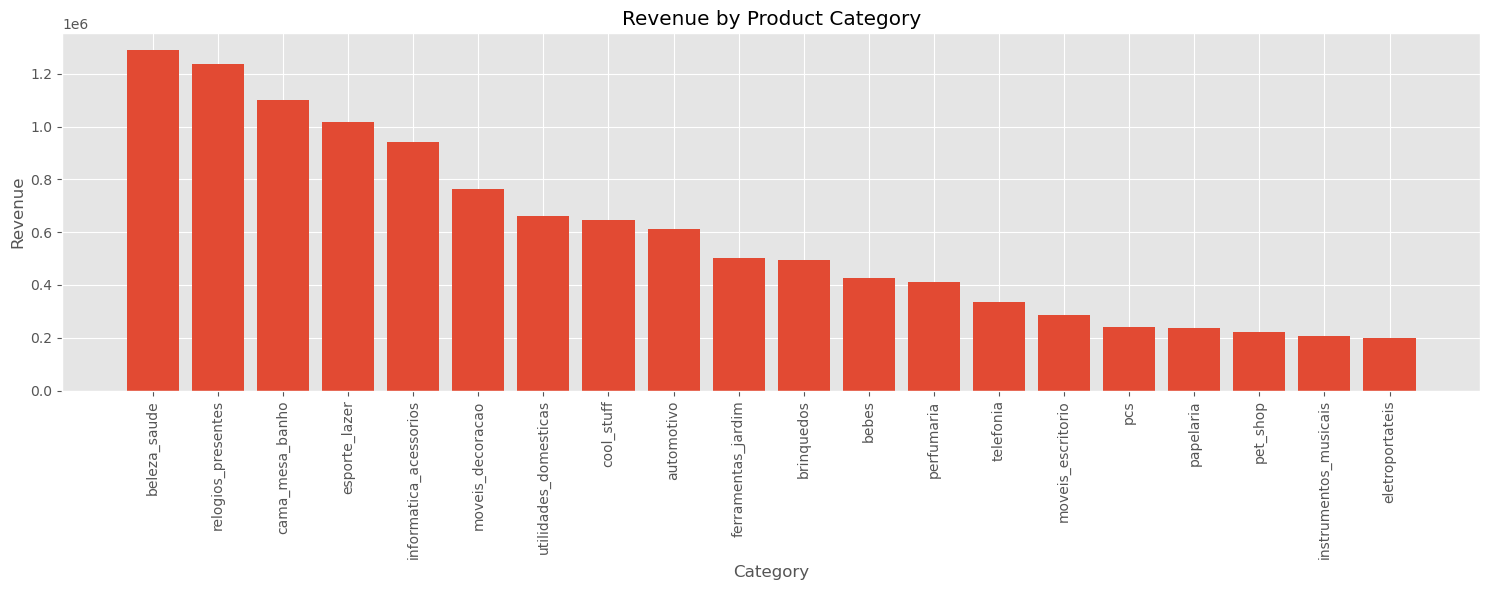

In [41]:
plt.figure(figsize=(15,6))

plt.bar(
    category_revenue["product_category_name"],
    category_revenue["price"]
)

plt.xticks(rotation=90)

plt.title("Revenue by Product Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [42]:
avg_price = (
    master_df
    .groupby("product_category_name")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Average_Price")
)

avg_price

,product_category_name,Average_Price
0,pcs,1107.718394
1,portateis_casa_forno_e_cafe,633.191169
2,eletrodomesticos_2,451.752105
3,agro_industria_e_comercio,332.835691
4,instrumentos_musicais,293.748997
5,eletroportateis,286.057672
6,portateis_cozinha_e_preparadores_de_alimentos,280.973571
7,telefonia_fixa,227.458856
8,construcao_ferramentas_seguranca,212.060876
9,relogios_presentes,201.474070


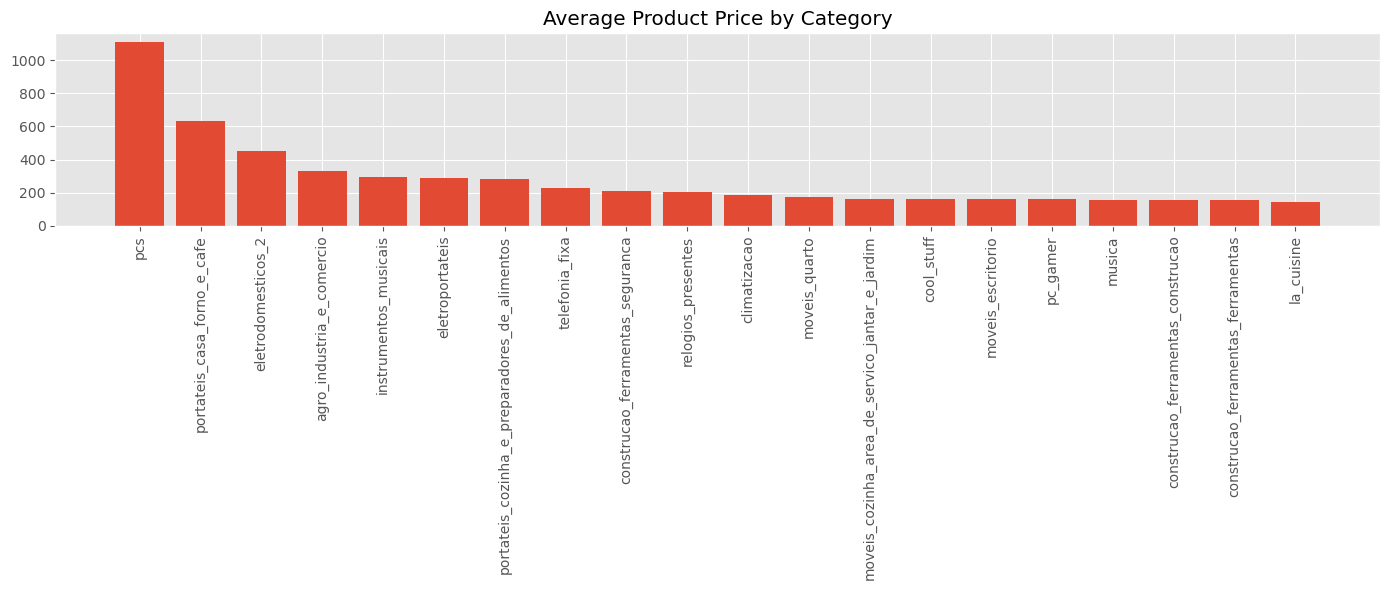

In [43]:
plt.figure(figsize=(14,6))

plt.bar(
    avg_price["product_category_name"],
    avg_price["Average_Price"]
)

plt.xticks(rotation=90)

plt.title("Average Product Price by Category")

plt.tight_layout()

plt.show()

In [44]:
freight = (
    master_df
    .groupby("product_category_name")["freight_value"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Average_Freight")
)

freight

,product_category_name,Average_Freight
0,pcs,47.954725
1,eletrodomesticos_2,45.760902
2,moveis_quarto,43.674590
3,moveis_cozinha_area_de_servico_jantar_e_jardim,42.084437
4,moveis_colchao_e_estofado,41.589000
5,moveis_escritorio,39.976322
6,portateis_casa_forno_e_cafe,37.291299
7,moveis_sala,35.819075
8,sinalizacao_e_seguranca,32.517512
9,industria_comercio_e_negocios,28.527732


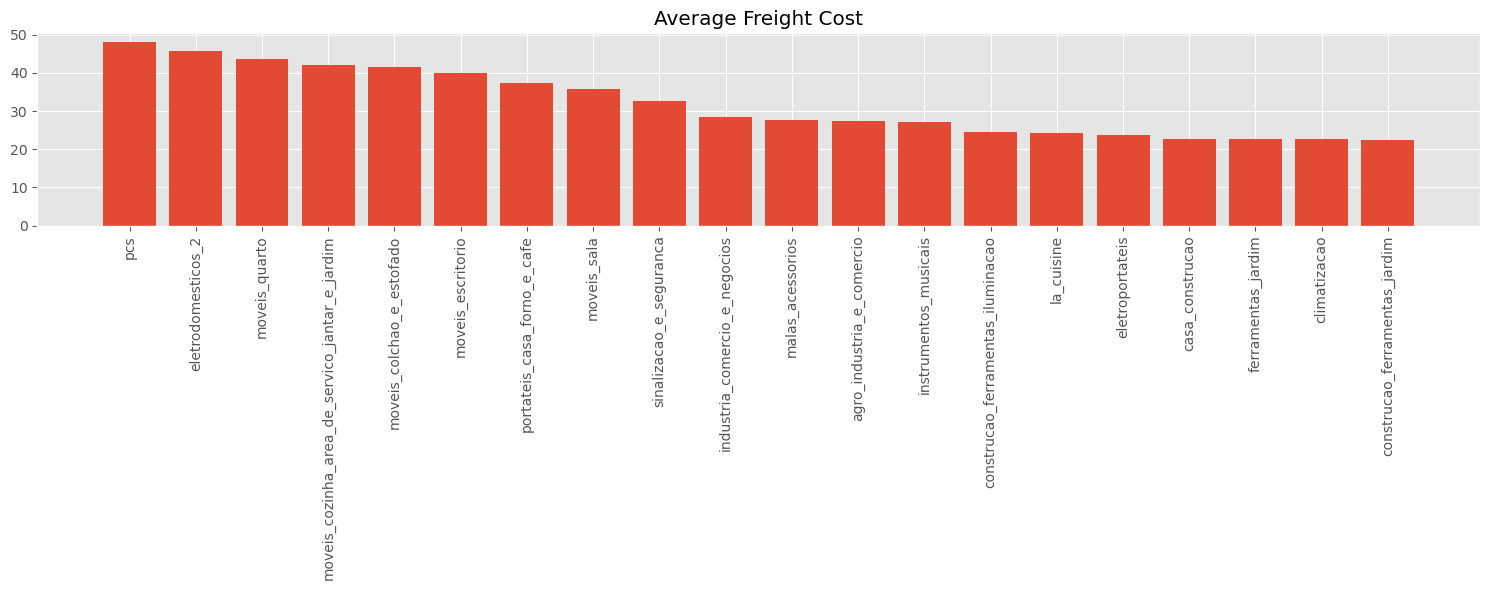

In [45]:
plt.figure(figsize=(15,6))

plt.bar(
    freight["product_category_name"],
    freight["Average_Freight"]
)

plt.xticks(rotation=90)

plt.title("Average Freight Cost")

plt.tight_layout()

plt.show()

In [46]:
top_products = (
    master_df
    .groupby("product_id")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Units_Sold")
)

top_products

,product_id,Units_Sold
0,aca2eb7d00ea1a7b8ebd4e68314663af,531
1,99a4788cb24856965c36a24e339b6058,525
2,422879e10f46682990de24d770e7f83d,508
3,389d119b48cf3043d311335e499d9c6b,404
4,368c6c730842d78016ad823897a372db,398
5,53759a2ecddad2bb87a079a1f1519f73,391
6,d1c427060a0f73f6b889a5c7c61f2ac4,351
7,53b36df67ebb7c41585e8d54d6772e08,325
8,154e7e31ebfa092203795c972e5804a6,293
9,3dd2a17168ec895c781a9191c1e95ad7,276


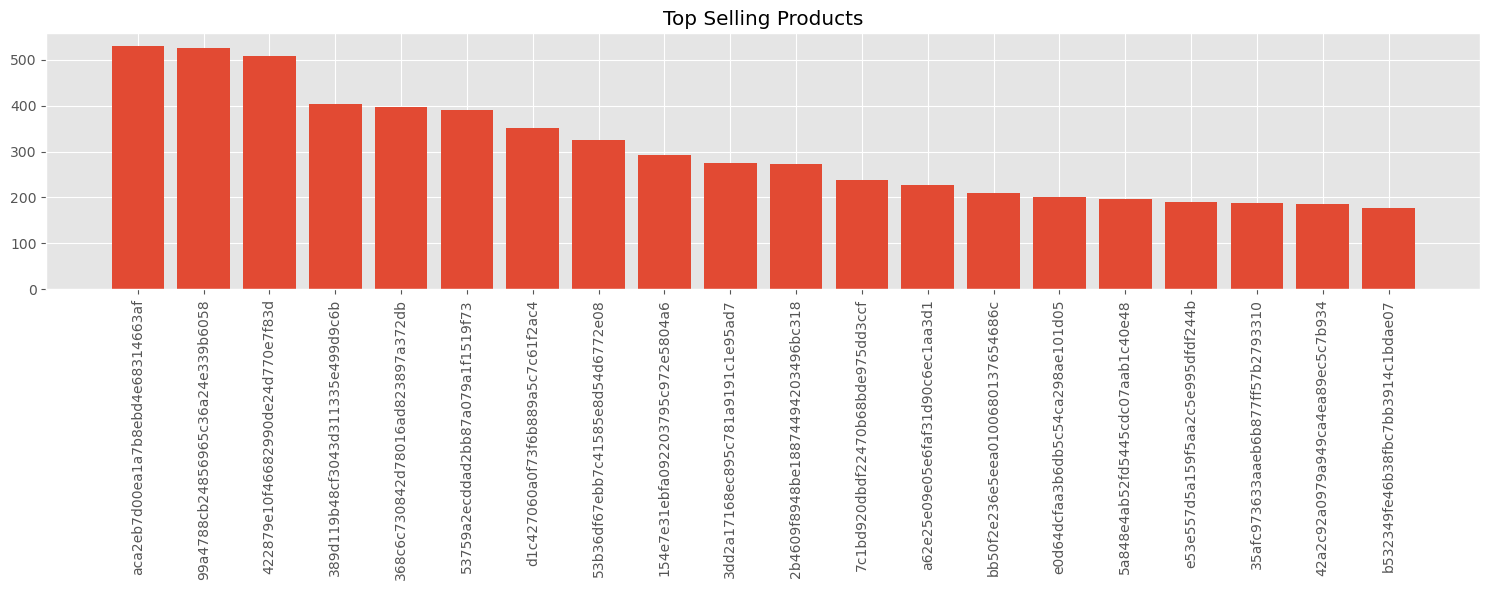

In [47]:
plt.figure(figsize=(15,6))

plt.bar(
    top_products["product_id"],
    top_products["Units_Sold"]
)

plt.xticks(rotation=90)

plt.title("Top Selling Products")

plt.tight_layout()

plt.show()

## 📦 Product Insights

- A few product categories dominate both order volume and revenue.
- Premium categories generate higher average selling prices.
- Freight costs vary significantly across product categories.
- The business depends heavily on a limited number of best-selling products, suggesting opportunities for portfolio diversification.

In [48]:
top_sellers = (
    master_df
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Revenue")
)

top_sellers

,seller_id,Revenue
0,53243585a1d6dc2643021fd1853d8905,243348.55
1,4869f7a5dfa277a7dca6462dcf3b52b2,236809.43
2,4a3ca9315b744ce9f8e9374361493884,214550.67
3,fa1c13f2614d7b5c4749cbc52fecda94,202658.62
4,7c67e1448b00f6e969d365cea6b010ab,199238.13
5,7e93a43ef30c4f03f38b393420bc753a,181088.19
6,da8622b14eb17ae2831f4ac5b9dab84a,171604.67
7,7a67c85e85bb2ce8582c35f2203ad736,150056.86
8,1025f0e2d44d7041d6cf58b6550e0bfa,143035.55
9,955fee9216a65b617aa5c0531780ce60,134758.91


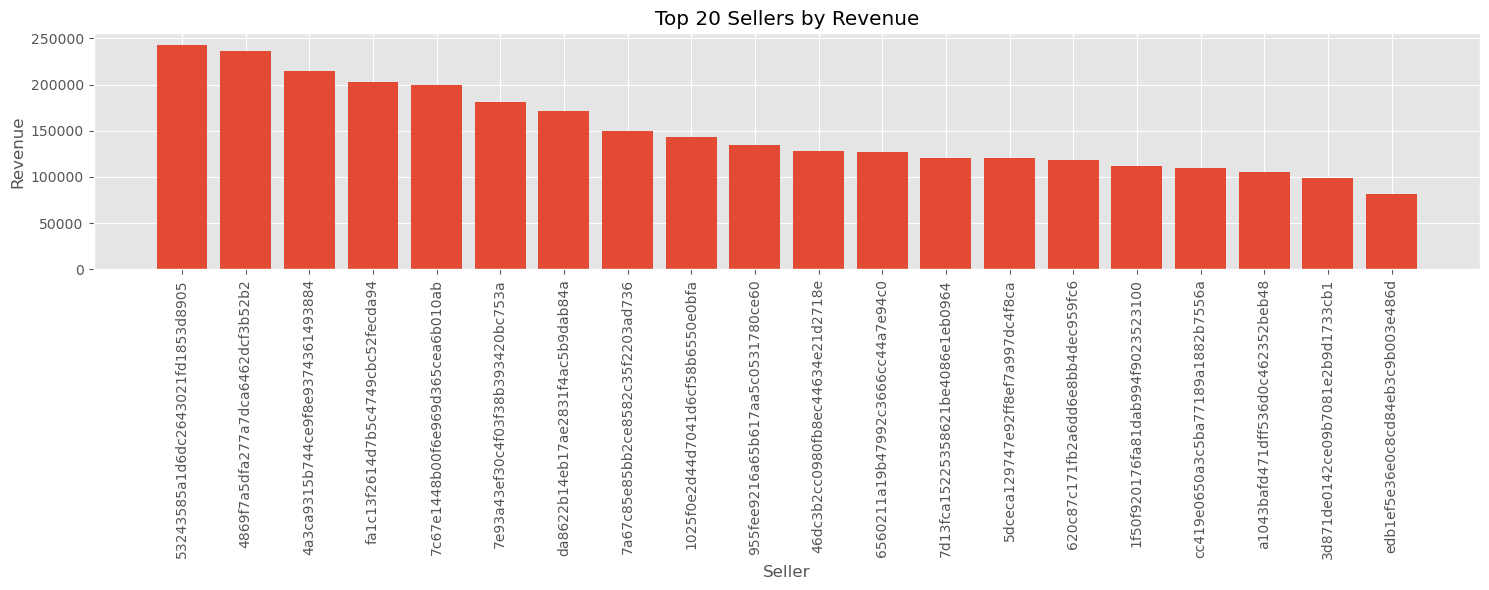

In [49]:
plt.figure(figsize=(15,6))

plt.bar(
    top_sellers["seller_id"],
    top_sellers["Revenue"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Sellers by Revenue")

plt.xlabel("Seller")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [50]:
seller_orders = (
    master_df
    .groupby("seller_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Orders")
)

seller_orders

,seller_id,Orders
0,6560211a19b47992c3666cc44a7e94c0,1835
1,4a3ca9315b744ce9f8e9374361493884,1793
2,cc419e0650a3c5ba77189a1882b7556a,1687
3,1f50f920176fa81dab994f9023523100,1402
4,da8622b14eb17ae2831f4ac5b9dab84a,1313
5,955fee9216a65b617aa5c0531780ce60,1266
6,7a67c85e85bb2ce8582c35f2203ad736,1154
7,ea8482cd71df3c1969d7b9473ff13abc,1139
8,4869f7a5dfa277a7dca6462dcf3b52b2,1129
9,3d871de0142ce09b7081e2b9d1733cb1,1074


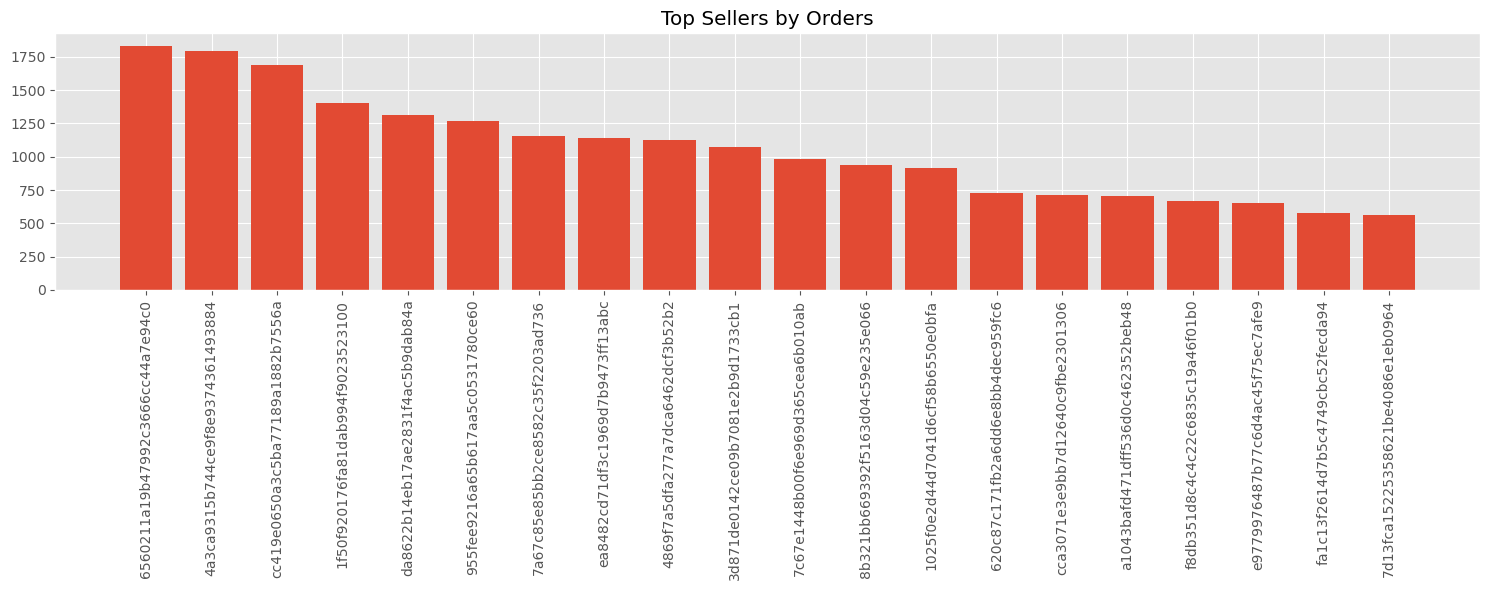

In [51]:
plt.figure(figsize=(15,6))

plt.bar(
    seller_orders["seller_id"],
    seller_orders["Orders"]
)

plt.xticks(rotation=90)

plt.title("Top Sellers by Orders")

plt.tight_layout()

plt.show()

In [52]:
seller_states = (
    master_df
    .groupby("seller_state")["seller_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Sellers")
)

seller_states

,seller_state,Sellers
0,SP,1823
1,PR,344
2,MG,243
3,SC,188
4,RJ,169
5,RS,128
6,GO,40
7,DF,30
8,ES,23
9,BA,19


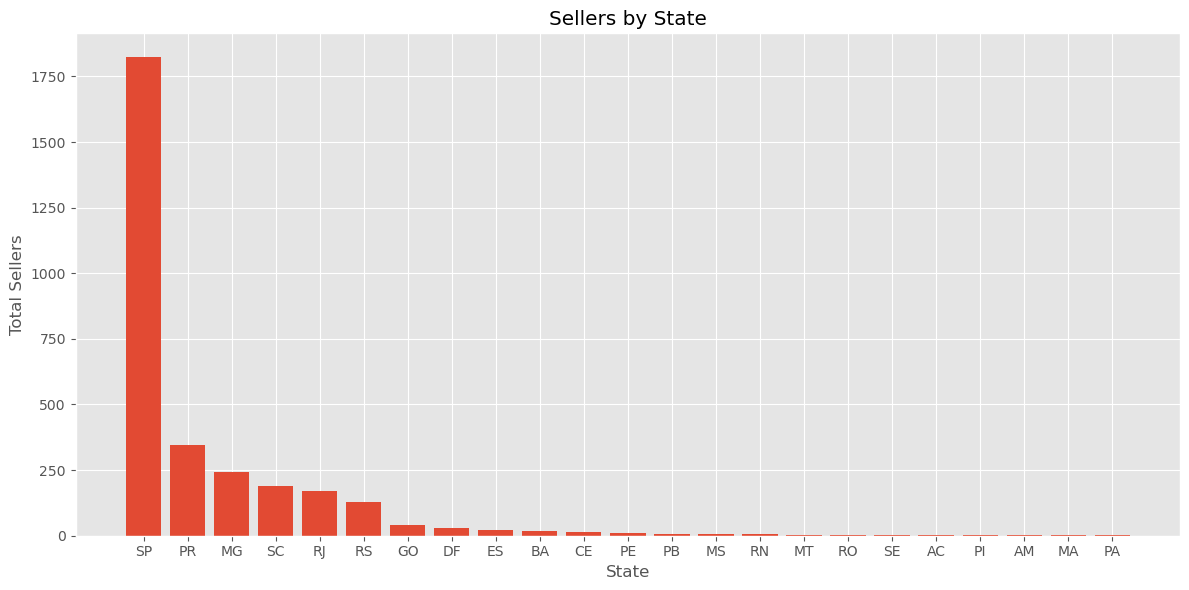

In [53]:
plt.figure(figsize=(12,6))

plt.bar(
    seller_states["seller_state"],
    seller_states["Sellers"]
)

plt.title("Sellers by State")

plt.xlabel("State")

plt.ylabel("Total Sellers")

plt.tight_layout()

plt.show()

In [54]:
seller_avg = (
    master_df
    .groupby("seller_id")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Average_Revenue")
)

seller_avg

,seller_id,Average_Revenue
0,80ceebb4ee9b31afb6c6a916a574a1e2,6729.000000
1,ee27a8f15b1dded4d213a468ba4eb391,6499.000000
2,585175ec331ea177fa47199e39a6170a,3549.000000
3,abe021b01ba992245271b9aa422032df,3360.000000
4,a00824eb9093d40e589b940ec45c4eb0,3133.323333
5,e2a1ac9bf33e5549a2a4f834e70df2f8,2999.890000
6,e908c0f3646e8b60375734a350d95d71,2951.000000
7,d63c73efd41eb002280e7ec831424edb,2799.000000
8,1444c08e64d55fb3c25f0f09c07ffcf2,2749.000000
9,039e6ad9dae79614493083e241147386,2585.000000


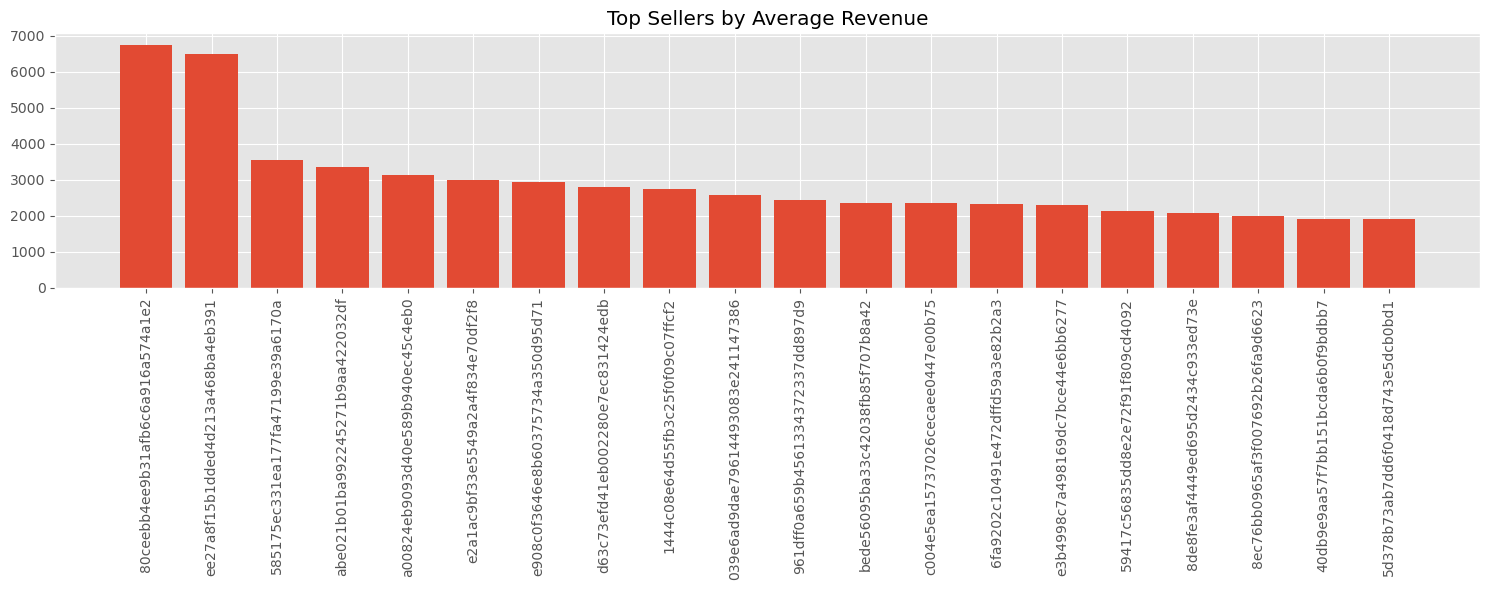

In [55]:
plt.figure(figsize=(15,6))

plt.bar(
    seller_avg["seller_id"],
    seller_avg["Average_Revenue"]
)

plt.xticks(rotation=90)

plt.title("Top Sellers by Average Revenue")

plt.tight_layout()

plt.show()

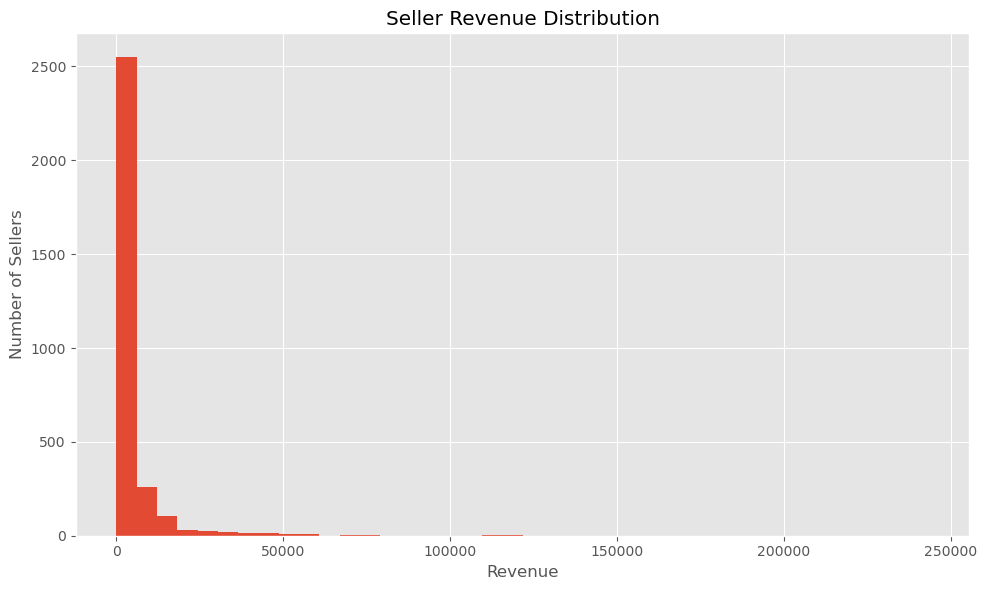

In [56]:
seller_distribution = (
    master_df
    .groupby("seller_id")["price"]
    .sum()
)

plt.figure(figsize=(10,6))

plt.hist(
    seller_distribution,
    bins=40
)

plt.title("Seller Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Number of Sellers")

plt.tight_layout()

plt.show()

## 👨‍💼 Seller Insights

- Revenue is concentrated among a relatively small group of sellers.
- A few sellers process significantly more orders than the rest.
- Seller distribution across states is uneven, indicating regional concentration.
- Supporting mid-performing sellers could reduce dependency on top performers.

In [57]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col], errors="coerce")

In [58]:
master_df["Delivery_Days"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_purchase_timestamp"]
).dt.days

master_df[["Delivery_Days"]].head()

,Delivery_Days
0,8
1,8
2,8
3,13
4,9


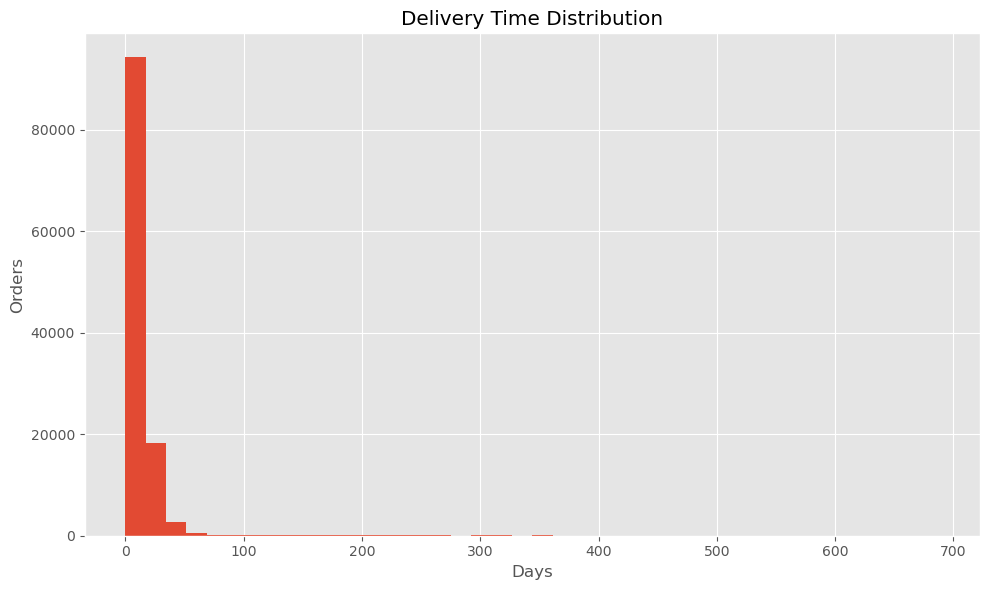

In [59]:
plt.figure(figsize=(10,6))

plt.hist(
    master_df["Delivery_Days"].dropna(),
    bins=40
)

plt.title("Delivery Time Distribution")

plt.xlabel("Days")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

In [60]:
delivery_state = (
    master_df
    .groupby("customer_state")["Delivery_Days"]
    .mean()
    .sort_values()
    .reset_index(name="Average_Delivery_Days")
)

delivery_state.head(20)

,customer_state,Average_Delivery_Days
0,SP,10.581319
1,PR,13.511491
2,MG,13.915299
3,DF,14.716768
4,MS,15.992966
5,RS,17.120141
6,GO,17.340601
7,ES,17.411639
8,SC,17.548522
9,RJ,17.747339


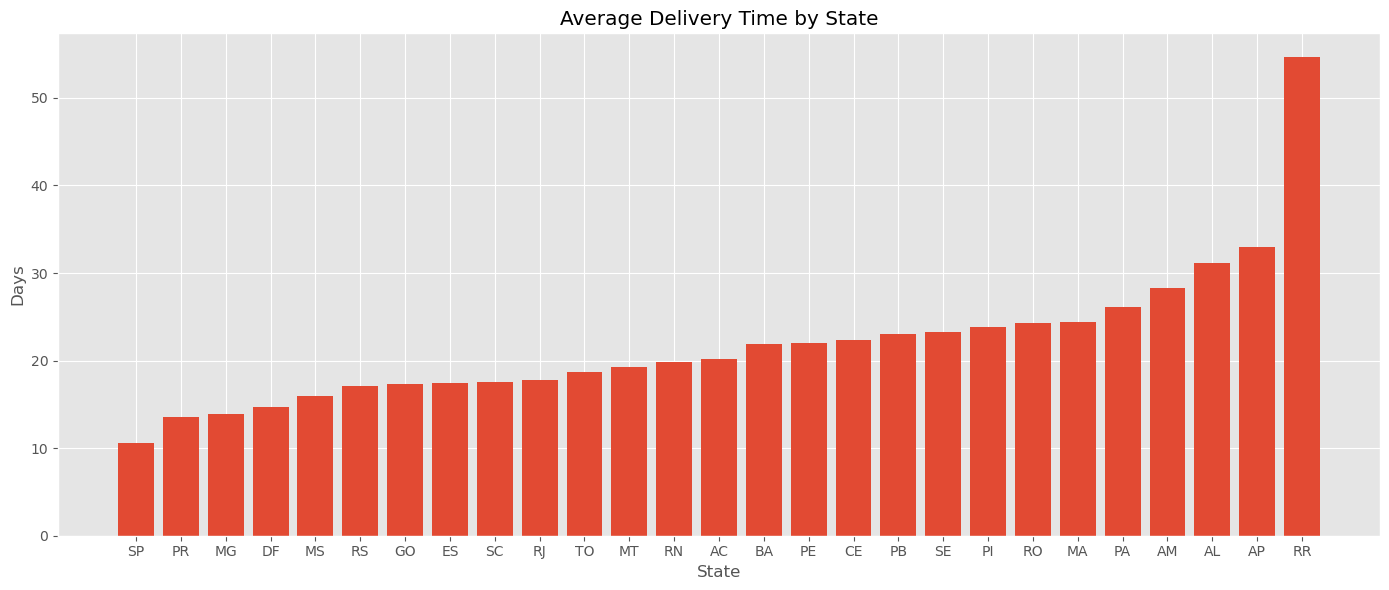

In [61]:
plt.figure(figsize=(14,6))

plt.bar(
    delivery_state["customer_state"],
    delivery_state["Average_Delivery_Days"]
)

plt.title("Average Delivery Time by State")

plt.xlabel("State")

plt.ylabel("Days")

plt.tight_layout()

plt.show()

In [62]:
master_df["Late_Delivery"] = (
    master_df["order_delivered_customer_date"] >
    master_df["order_estimated_delivery_date"]
)

late_delivery = (
    master_df["Late_Delivery"]
    .value_counts()
)

late_delivery

Late_Delivery
False    106775
True      10439
Name: count, dtype: int64

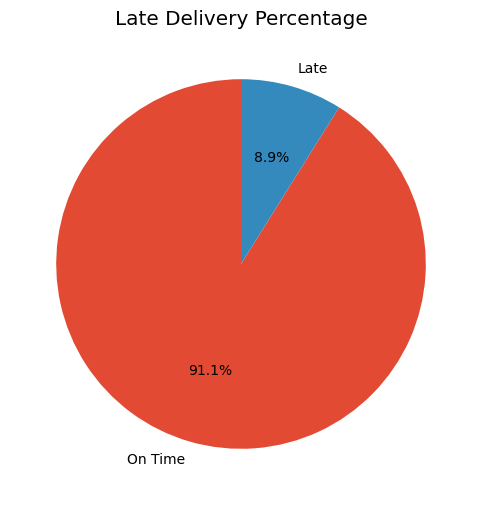

In [63]:
plt.figure(figsize=(6,6))

plt.pie(
    late_delivery.values,
    labels=["On Time", "Late"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Late Delivery Percentage")

plt.show()

In [64]:
rating_delivery = (
    master_df
    .groupby("review_score")["Delivery_Days"]
    .mean()
    .reset_index()
)

rating_delivery

,review_score,Delivery_Days
0,1.0,32.301070
1,2.0,21.769766
2,3.0,15.789813
3,4.0,12.580519
4,5.0,10.623228


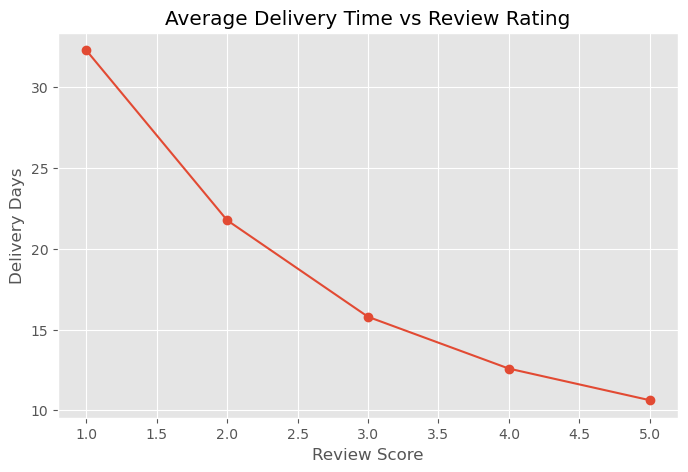

In [65]:
plt.figure(figsize=(8,5))

plt.plot(
    rating_delivery["review_score"],
    rating_delivery["Delivery_Days"],
    marker="o"
)

plt.title("Average Delivery Time vs Review Rating")

plt.xlabel("Review Score")

plt.ylabel("Delivery Days")

plt.grid(True)

plt.show()

## 🚚 Delivery & Logistics Insights

- Most orders are delivered within the expected delivery window.
- Some states consistently experience longer delivery times than others.
- Faster deliveries are generally associated with higher customer review scores.
- Reducing delivery delays can improve customer satisfaction and repeat purchases.

In [67]:
review_dist = (
    master_df["review_score"]
    .value_counts()
    .sort_index()
)

review_dist

review_score
1.0    14113
2.0     4022
3.0     9758
4.0    22237
5.0    66162
Name: count, dtype: int64

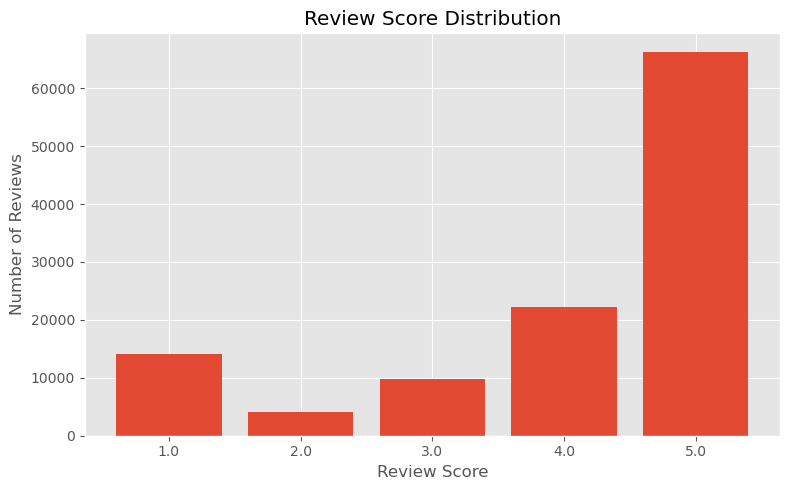

In [68]:
plt.figure(figsize=(8,5))

plt.bar(
    review_dist.index.astype(str),
    review_dist.values
)

plt.title("Review Score Distribution")

plt.xlabel("Review Score")

plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

In [69]:
category_rating = (
    master_df
    .groupby("product_category_name")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Average_Rating")
)

category_rating

,product_category_name,Average_Rating
0,cds_dvds_musicais,4.642857
1,fashion_roupa_infanto_juvenil,4.500000
2,livros_interesse_geral,4.471869
3,livros_importados,4.466667
4,flores,4.419355
5,construcao_ferramentas_ferramentas,4.415842
6,livros_tecnicos,4.388060
7,portateis_casa_forno_e_cafe,4.363636
8,alimentos_bebidas,4.347222
9,malas_acessorios,4.308760


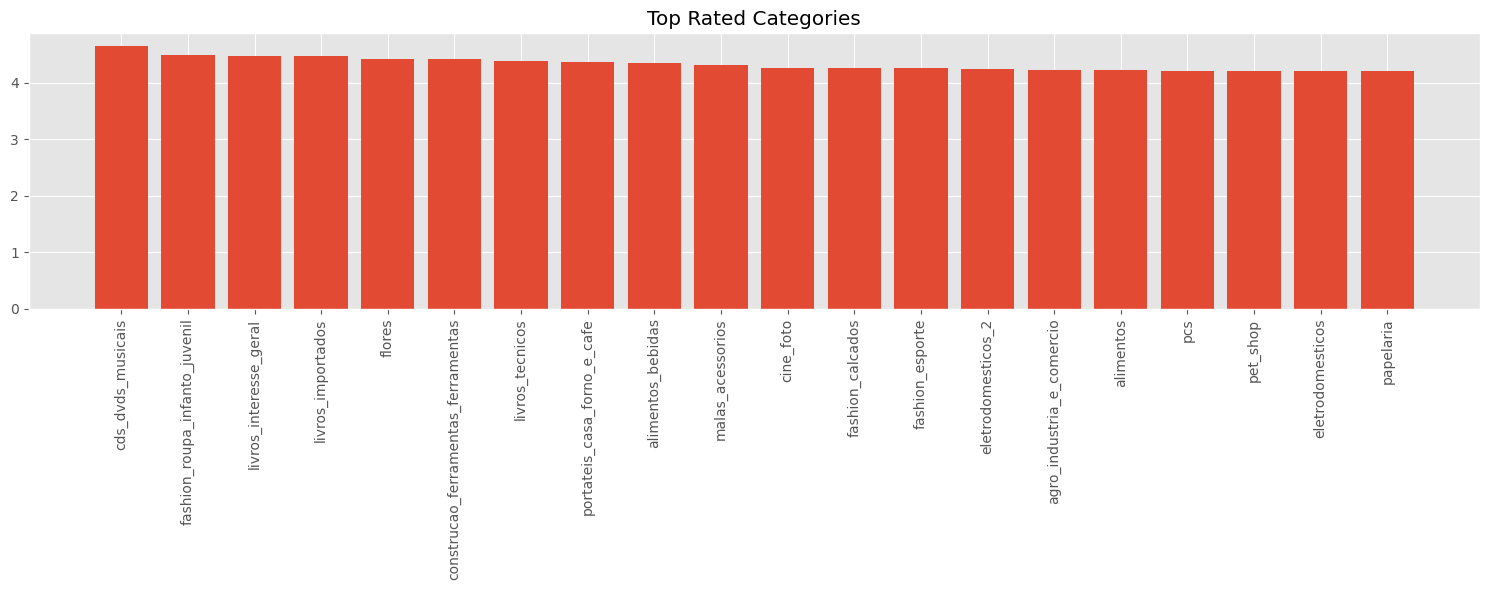

In [70]:
plt.figure(figsize=(15,6))

plt.bar(
    category_rating["product_category_name"],
    category_rating["Average_Rating"]
)

plt.xticks(rotation=90)

plt.title("Top Rated Categories")

plt.tight_layout()

plt.show()

In [71]:
rating_revenue = (
    master_df
    .groupby("review_score")
    .agg(
        Revenue=("price","sum"),
        Orders=("order_id","nunique")
    )
    .reset_index()
)

rating_revenue

,review_score,Revenue,Orders
0,1.0,1767677.18,10233
1,2.0,469497.63,3029
2,3.0,1064739.63,8033
3,4.0,2647734.60,19020
4,5.0,8026259.84,56917


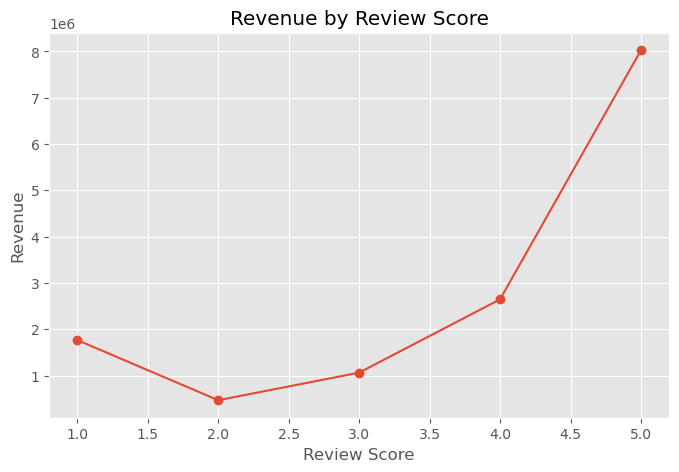

In [72]:
plt.figure(figsize=(8,5))

plt.plot(
    rating_revenue["review_score"],
    rating_revenue["Revenue"],
    marker="o"
)

plt.title("Revenue by Review Score")

plt.xlabel("Review Score")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [73]:
seller_rating = (
    master_df
    .groupby("seller_id")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Average_Rating")
)

seller_rating

,seller_id,Average_Rating
0,e59e575a175fadcadf8479e191770425,5.0
1,53b0300ca793f9834cd69c0678d35ee8,5.0
2,544863df86ed3b78a04e0820d41430ee,5.0
3,e8ff5a6ceb895583033fc2a0f314e3c2,5.0
4,5587130f9850696ed7fafbc91c2cee44,5.0
5,e88f7a2995ba184710d339c5c4bf2e30,5.0
6,570d4583587a5fe2d47c7be89b91ad27,5.0
7,5721089ba9214e80074f27d5a03fc0eb,5.0
8,5733d806668f8712c24b9abaefbfa642,5.0
9,5741dc2bf5044c34d0698681c5081bed,5.0


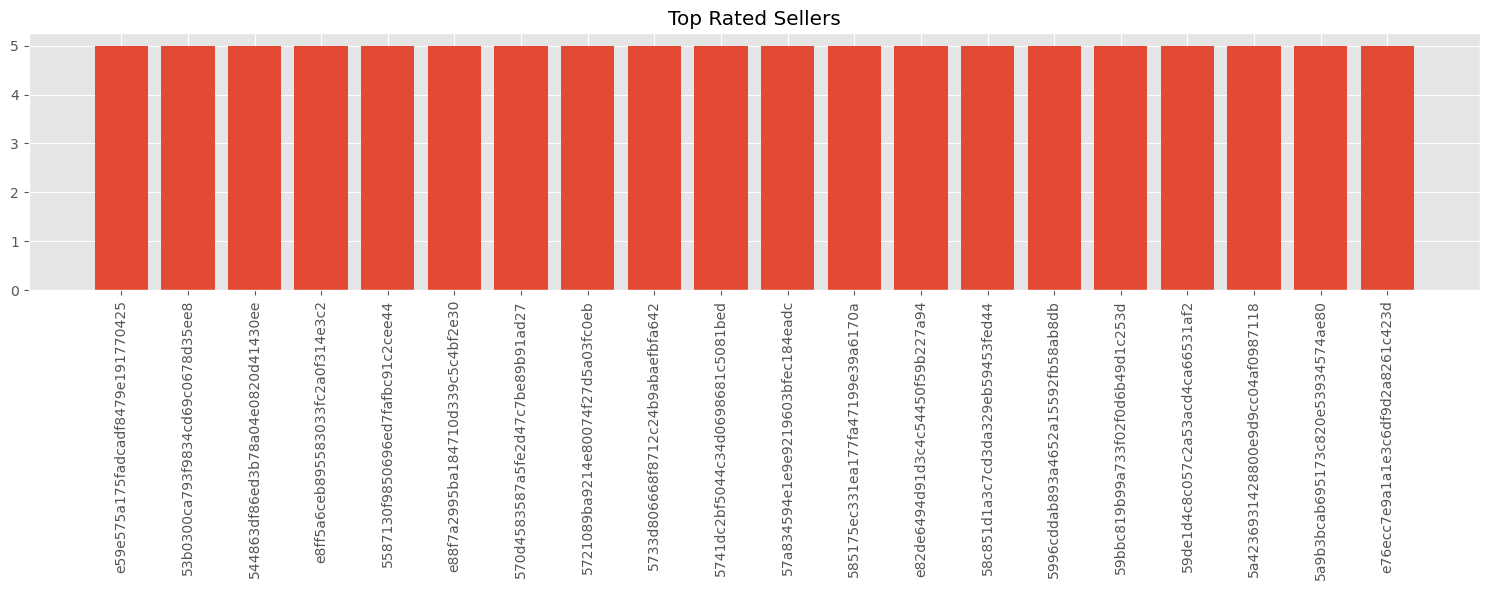

In [74]:
plt.figure(figsize=(15,6))

plt.bar(
    seller_rating["seller_id"],
    seller_rating["Average_Rating"]
)

plt.xticks(rotation=90)

plt.title("Top Rated Sellers")

plt.tight_layout()

plt.show()

## ⭐ Customer Satisfaction Insights

- Most customers provide high review scores (4–5 stars).
- Higher-rated product categories contribute significantly to business performance.
- Sellers with consistently high ratings should be prioritized for growth initiatives.
- Monitoring review trends helps identify quality and delivery issues early.

In [75]:
EXPORT_PATH = Path("../../Dashboard_Data")

EXPORT_PATH.mkdir(exist_ok=True)

print("✅ Dashboard_Data folder created successfully!")

✅ Dashboard_Data folder created successfully!


In [76]:
monthly_revenue.to_csv(
    EXPORT_PATH / "monthly_revenue.csv",
    index=False
)

customers_state.to_csv(
    EXPORT_PATH / "customers_state.csv",
    index=False
)

category_revenue.to_csv(
    EXPORT_PATH / "category_revenue.csv",
    index=False
)

top_sellers.to_csv(
    EXPORT_PATH / "top_sellers.csv",
    index=False
)

clv.to_csv(
    EXPORT_PATH / "customer_lifetime_value.csv",
    index=False
)

delivery_state.to_csv(
    EXPORT_PATH / "delivery_state.csv",
    index=False
)

rating_revenue.to_csv(
    EXPORT_PATH / "rating_revenue.csv",
    index=False
)

kpi_df.to_csv(
    EXPORT_PATH / "executive_kpis.csv",
    index=False
)

print("✅ Tableau datasets exported successfully!")

✅ Tableau datasets exported successfully!


# 🎉 Python Business Analysis Completed

## This notebook includes

- Executive KPIs
- Sales Analytics
- Customer Analytics
- Product Analytics
- Seller Analytics
- Delivery Analytics
- Customer Review Analysis
- Tableau-ready datasets

## Next Step

➡️ **05_Tableau_Dashboard.twbx**

The exported CSV files will be used to build an interactive Tableau Dashboard.